# Scikit-learn

Everything uses NumPy arrays, CSV files, and scikit-learn objects.

The pattern to remember:

```text
X matrix + y target → split → preprocess → fit → predict → evaluate → improve
```

We will cover loading data, preprocessing, classification, regression, model comparison, tuning, clustering, PCA, and saving a trained pipeline.

In [1]:
import sklearn
print('scikit-learn version:', sklearn.__version__)
print('This course uses no pandas import.')

scikit-learn version: 1.8.0
This course uses no pandas import.


In [2]:
from pathlib import Path
import csv, math, warnings
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('Data')
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
np.set_printoptions(precision=3, suppress=True)
warnings.filterwarnings('ignore', category=FutureWarning)

def load_mixed_csv(path, target_column):
    with open(path, newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        header = next(reader)
        rows = list(reader)
    target_index = header.index(target_column)
    feature_names = [name for i, name in enumerate(header) if i != target_index]
    X_rows, y_values = [], []
    for row in rows:
        X_rows.append([value for i, value in enumerate(row) if i != target_index])
        y_values.append(row[target_index])
    return np.array(X_rows, dtype=object), np.array(y_values), feature_names

def convert_numeric_columns(X, numeric_indices):
    X = X.copy()
    for idx in numeric_indices:
        X[:, idx] = [np.nan if value == '' else float(value) for value in X[:, idx]]
    return X

def print_classification_scores(y_true, y_pred):
    from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
    print('accuracy:', accuracy_score(y_true, y_pred))
    print('f1:', f1_score(y_true, y_pred))
    print('confusion matrix:')
    print(confusion_matrix(y_true, y_pred))

def print_regression_scores(y_true, y_pred):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    print('MAE:', mean_absolute_error(y_true, y_pred))
    print('RMSE:', math.sqrt(mean_squared_error(y_true, y_pred)))
    print('R2:', r2_score(y_true, y_pred))

## 1. The scikit-learn logic

Most objects follow a small vocabulary:

- `fit`: learn from data.
- `predict`: make predictions.
- `transform`: change data into a model-ready form.
- `score`: compute a default score.

`X` is a 2D feature matrix. `y` is the target vector.

In [7]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

print('X shape:', X.shape)
print('y shape:', y.shape)
print('feature names:', iris.feature_names)
print('class names:', iris.target_names)
print('\nFirst 5 rows of X:')
print(X[:5])
print('First 5 labels:', y[:5])
print(type(X))

X shape: (150, 4)
y shape: (150,)
feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
class names: ['setosa' 'versicolor' 'virginica']

First 5 rows of X:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
First 5 labels: [0 0 0 0 0]
<class 'numpy.ndarray'>


In [8]:
def describe_array(name, arr):
    arr = np.asarray(arr)
    print(f'{name}: shape={arr.shape}, dtype={arr.dtype}')
    if arr.ndim == 2:
        print('  first row:', arr[0])
    else:
        values, counts = np.unique(arr, return_counts=True)
        print('  value counts:', dict(zip(values.tolist(), counts.tolist())))

describe_array('X', X)
describe_array('y', y)

X: shape=(150, 4), dtype=float64
  first row: [5.1 3.5 1.4 0.2]
y: shape=(150,), dtype=int32
  value counts: {0: 50, 1: 50, 2: 50}


## 2. First classification model

Classification predicts a label: pass/fail, fraud/not fraud, class A/B/C. The first working model is usually more valuable than a perfect-looking notebook.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('accuracy:', accuracy_score(y_test, y_pred))
print('\nconfusion matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nclassification report:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

accuracy: 0.9473684210526315

confusion matrix:
[[12  0  0]
 [ 0 12  1]
 [ 0  1 12]]

classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



## 3. Loading data without pandas

For numeric-only CSV files, NumPy is enough.

Real CSV files often mix numbers and categories. We will load them as an object array, then convert only the numeric columns.

In [10]:
X_clinic_raw, y_clinic_raw, clinic_features = load_mixed_csv(DATA_DIR / 'USA_Housing.csv', 'needs_followup')
y_clinic = y_clinic_raw.astype(int)

print('feature names:')
for i, name in enumerate(clinic_features):
    print(f'{i}: {name}')
print('\nraw first row:', X_clinic_raw[0])

numeric_cols = [clinic_features.index(name) for name in ['age','bmi','systolic_bp','cholesterol','visits_last_year']]
categorical_cols = [clinic_features.index(name) for name in ['smoker','exercise_level','sex']]
X_clinic = convert_numeric_columns(X_clinic_raw, numeric_cols)
print('converted first row:', X_clinic[0])

FileNotFoundError: [Errno 2] No such file or directory: 'Data\\USA_Housing.csv'

## 4. Preprocessing with pipelines

Useful preprocessing pieces:

- `SimpleImputer` fills missing values.
- `StandardScaler` scales numeric columns.
- `OneHotEncoder` converts categories to numeric columns.
- `ColumnTransformer` applies different steps to different columns.
- `Pipeline` keeps preprocessing and modeling together.

The pipeline is not decorative. It prevents data leakage during cross-validation and tuning.

strategy='`mean`'
strategy='`median`'
strategy='`most_frequent`'
strategy='`constant`'

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score

numeric_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_preprocess = Pipeline([
    ('imputer', SimpleImputer(missing_values='', strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocess = ColumnTransformer([
    ('num', numeric_preprocess, numeric_cols),
    ('cat', categorical_preprocess, categorical_cols),
])

clf_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000)),
])

X_train, X_test, y_train, y_test = train_test_split(
    X_clinic, y_clinic, test_size=0.25, random_state=RANDOM_STATE, stratify=y_clinic
)
clf_pipe.fit(X_train, y_train)
y_pred = clf_pipe.predict(X_test)
y_prob = clf_pipe.predict_proba(X_test)[:, 1]

print('accuracy:', accuracy_score(y_test, y_pred))
print('f1:', f1_score(y_test, y_pred))
print('roc_auc:', roc_auc_score(y_test, y_prob))
print('\nconfusion matrix:')
print(confusion_matrix(y_test, y_pred))

accuracy: 0.8260869565217391
f1: 0.5238095238095238
roc_auc: 0.7902930402930403

confusion matrix:
[[84  7]
 [13 11]]


## 5. Main classification algorithms

The point is not to crown a universal winner. The point is to compare several reasonable candidates using the same validation setup.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

classifiers = {
    'logistic_regression': LogisticRegression(max_iter=1000),
    'knn': KNeighborsClassifier(n_neighbors=9),
    'decision_tree': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    'random_forest': RandomForestClassifier(n_estimators=80, random_state=RANDOM_STATE),
    'svm_rbf': SVC(kernel='rbf', C=1.0, gamma='scale'),
    'gaussian_nb': GaussianNB(),
}

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in classifiers.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', model)])
    scores = cross_validate(pipe, X_clinic, y_clinic, cv=cv, scoring=['accuracy','f1'], n_jobs=1)
    # print(scores)
    results.append((name, scores['test_accuracy'].mean(), scores['test_f1'].mean()))

print(f"{'model':25s} {'accuracy':>10s} {'f1':>10s}")
print('-' * 50)
for name, acc, f1 in sorted(results, key=lambda row: row[2], reverse=True):
    print(f"{name:25s} {acc:10.3f} {f1:10.3f}")

model                       accuracy         f1
--------------------------------------------------
gaussian_nb                    0.809      0.571
logistic_regression            0.830      0.486
random_forest                  0.809      0.408
knn                            0.822      0.387
svm_rbf                        0.811      0.350
decision_tree                  0.763      0.298


Quick reading guide:

- Logistic regression: excellent baseline.
- kNN: simple but sensitive to scaling.
- Decision tree: readable but can overfit.
- Random forest: strong default for tabular data.
- Gradient boosting: often very strong on structured data.
- SVM: powerful, but parameter-sensitive.
- Naive Bayes: fast baseline.

## 6. Hyperparameter tuning with `GridSearchCV`

Pipeline parameters use double underscores. Example: `model__max_depth` means the `max_depth` parameter inside the pipeline step named `model`.

In [ ]:
from sklearn.model_selection import GridSearchCV

search_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE)),
])
param_grid = {
    'model__n_estimators': [60, 120],
    'model__max_depth': [4, None],
    'model__min_samples_leaf': [1, 6],
}

grid = GridSearchCV(search_pipe, param_grid=param_grid, scoring='f1', cv=cv, n_jobs=1)
grid.fit(X_train, y_train)

print('best cv f1:', grid.best_score_)
print('best parameters:', grid.best_params_)

best_clinic_model = grid.best_estimator_
test_pred = best_clinic_model.predict(X_test)
print('\nfinal test f1:', f1_score(y_test, test_pred))
print('final test accuracy:', accuracy_score(y_test, test_pred))

best cv f1: 0.3349145299145299
best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 60}

final test f1: 0.45
final test accuracy: 0.808695652173913


## 7. Regression: predicting a number

Regression predicts a continuous value. Use MAE, RMSE, and R² instead of accuracy.

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_data = load_diabetes()
X_reg, y_reg = reg_data.data, reg_data.target
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.25, random_state=RANDOM_STATE)

regressors = {
    'linear_regression': LinearRegression(),
    'ridge': Ridge(alpha=1.0),
    'lasso': Lasso(alpha=0.05, max_iter=10000),
    'random_forest': RandomForestRegressor(n_estimators=80, random_state=RANDOM_STATE),
}

print(f"{'model':24s} {'MAE':>9s} {'RMSE':>9s} {'R2':>9s}")
print('-' * 58)
for name, reg in regressors.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', reg)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    print(f"{name:24s} {mean_absolute_error(y_test, pred):9.2f} {math.sqrt(mean_squared_error(y_test, pred)):9.2f} {r2_score(y_test, pred):9.3f}")

model                          MAE      RMSE        R2
----------------------------------------------------------
linear_regression            41.55     53.37     0.485
ridge                        41.51     53.32     0.486
lasso                        41.52     53.32     0.486
random_forest                43.65     54.84     0.456


## 8. Regression with a mixed CSV

Same idea as classification: load, select numeric and categorical columns, preprocess, fit, evaluate.

In [ ]:
X_car_raw, y_car_raw, car_features = load_mixed_csv(DATA_DIR / 'used_cars.csv', 'price_eur')
y_car = y_car_raw.astype(float)
car_numeric = [car_features.index(name) for name in ['year','mileage','engine_size_l']]
car_categorical = [car_features.index(name) for name in ['fuel','transmission','brand_tier']]
X_car = convert_numeric_columns(X_car_raw, car_numeric)

car_preprocess = ColumnTransformer([
    ('num', numeric_preprocess, car_numeric),
    ('cat', categorical_preprocess, car_categorical),
])
car_model = Pipeline([
    ('preprocess', car_preprocess),
    ('model', RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)),
])
X_train, X_test, y_train, y_test = train_test_split(X_car, y_car, test_size=0.25, random_state=RANDOM_STATE)
car_model.fit(X_train, y_train)
pred = car_model.predict(X_test)

print_regression_scores(y_test, pred)
print('\nFirst 8 predictions vs actual values:')
for actual, estimated in zip(y_test[:8], pred[:8]):
    print(f'actual={actual:8.0f}  predicted={estimated:8.0f}')

MAE: 1772.648695652174
RMSE: 2432.308064172435
R2: 0.8951063768734142

First 8 predictions vs actual values:
actual=   21314  predicted=   18894
actual=   12822  predicted=   12214
actual=   13284  predicted=   14143
actual=   23274  predicted=   23051
actual=   31030  predicted=   27869
actual=   27055  predicted=   25567
actual=   23353  predicted=   23386
actual=   13842  predicted=   13788


## 9. Feature importance

Tree-based models can report feature importances. Use this as a clue, not as proof of causation.

In [ ]:
num_names = [car_features[i] for i in car_numeric]
onehot = car_model.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
cat_names = onehot.get_feature_names_out([car_features[i] for i in car_categorical])
all_feature_names = np.concatenate([num_names, cat_names])
importances = car_model.named_steps['model'].feature_importances_
order = np.argsort(importances)[::-1]

print('Top 10 feature importances:')
for idx in order[:10]:
    print(f'{all_feature_names[idx]:25s} {importances[idx]:.4f}')

plt.figure(figsize=(8, 4))
top = order[:10][::-1]
plt.barh(all_feature_names[top], importances[top])
plt.xlabel('importance')
plt.title('Top feature importances for used-car price')
plt.tight_layout()
plt.show()

## 10. Unsupervised learning: KMeans and PCA

Unsupervised learning has `X`, but no target `y`.

c:\Users\Raoof\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


cluster counts: {np.int32(0): np.int64(88), np.int32(1): np.int64(87), np.int32(2): np.int64(87), np.int32(3): np.int64(88)}


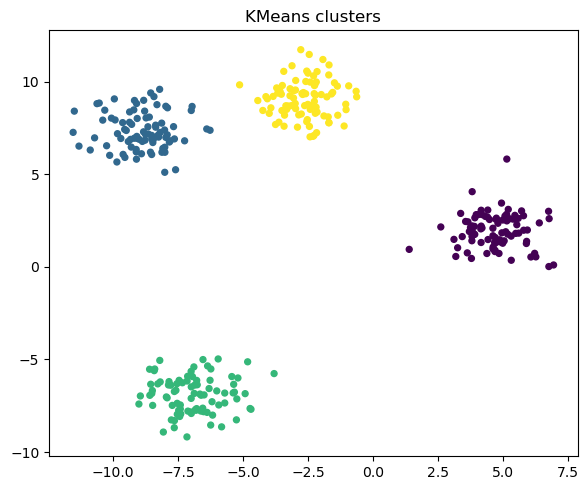

In [ ]:
from sklearn.datasets import make_blobs, load_digits
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X_blob, _ = make_blobs(n_samples=350, centers=4, cluster_std=1.0, random_state=RANDOM_STATE)
kmeans = Pipeline([('scaler', StandardScaler()), ('model', KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10))])
clusters = kmeans.fit_predict(X_blob)
print('cluster counts:', dict(zip(*np.unique(clusters, return_counts=True))))

plt.figure(figsize=(6, 5))

plt.scatter(X_blob[:, 0], X_blob[:, 1], c=clusters, s=18)
plt.title('KMeans clusters')
plt.tight_layout()
plt.show()

original shape: (1797, 64)
after PCA: (1797, 2)
explained variance ratio: [0.12  0.096]


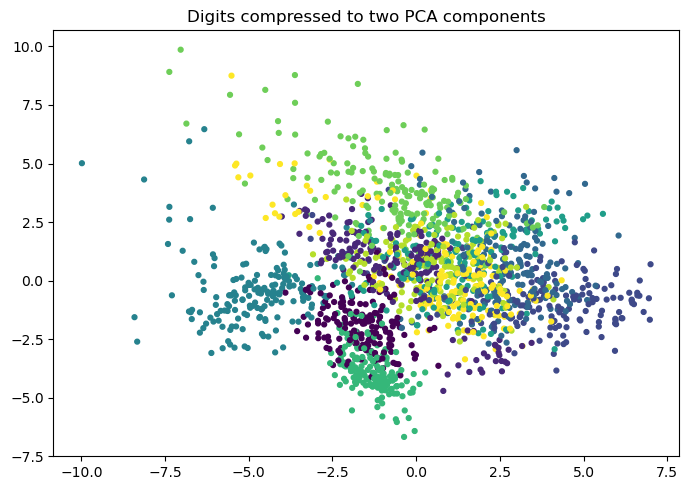

In [ ]:
digits = load_digits()
X_digits, y_digits = digits.data, digits.target
pca_pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=2, random_state=RANDOM_STATE))])
X_2d = pca_pipe.fit_transform(X_digits)
print('original shape:', X_digits.shape)
print('after PCA:', X_2d.shape)
print('explained variance ratio:', pca_pipe.named_steps['pca'].explained_variance_ratio_)

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_digits, s=12)
plt.title('Digits compressed to two PCA components')
plt.tight_layout()
plt.show()

## 11. Save the full pipeline

Save the fitted pipeline, not just the final estimator. The pipeline knows how to preprocess raw rows.

In [ ]:
import joblib

model_path = MODEL_DIR / 'clinic_followup_pipeline.joblib'
joblib.dump(best_clinic_model, model_path)
loaded_model = joblib.load(model_path)
print('saved to:', model_path)
print('sample predictions from loaded model:', loaded_model.predict(X_clinic[:5]))

## 12. Pocket reference

```python
# splitting and tuning
train_test_split, cross_validate, GridSearchCV, RandomizedSearchCV

# preprocessing
SimpleImputer, StandardScaler, OneHotEncoder, ColumnTransformer, Pipeline

# classification
LogisticRegression, KNeighborsClassifier, DecisionTreeClassifier,
RandomForestClassifier, GradientBoostingClassifier, SVC, GaussianNB

# regression
LinearRegression, Ridge, Lasso, RandomForestRegressor, GradientBoostingRegressor

# unsupervised
KMeans, PCA

# metrics
accuracy_score, f1_score, confusion_matrix, classification_report,
mean_absolute_error, mean_squared_error, r2_score
```

Practical recipe:

```text
load → inspect → split → pipeline → baseline → compare → tune → final test → save
```